In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Parameters and Reduced Units Selection

We have selected the parameters according to instruction

* **Reduced Temperature ($T^* = 0.1$):** Sets the physical state point where thermal energy ($k_B T = 0.1$) is small relative to the soft-shoulder energy step ($\epsilon = 1.0$). Operating at $10\%$ of the shoulder height ensures particles cannot easily jump onto each other's shoulders without strong thermal fluctuations, driving the formation of ordered microphases (like clusters and stripes).
* **Length Scale ($\sigma_0 = 1.0$):** Establishes the hard-core diameter as the primary unit of length. Scaling all distances relative to $\sigma_0$ eliminates the need to carry physical units like nanometers or Ångströms through the Monte Carlo algorithms[cite: 1].
* **Soft-Shoulder Diameter ($\sigma_1 = 2.5$):** Defines the range of the soft repulsive barrier to be $2.5$ times the hard-core diameter. This ratio creates a wide energetic "shelf" that forces particles to form patterned structures to optimize packing.
* **Energy Scale ($\epsilon = 1.0$) and Boltzmann Constant ($k_B = 1.0$):** Selecting $\epsilon = 1.0$ sets the height of the soft shoulder as the natural energy unit. Setting $k_B = 1.0$ directly equates temperature with thermal energy[cite: 1]. This avoids handling small numbers (such as $10^{-23}\text{ J/K}$) and prevents floating-point precision underflow during exponentiation in Metropolis acceptance checks ($e^{-\Delta E / T}$)[cite: 1].
* **Reduced Density ($\rho^*$) and Box Length ($L = \sqrt{N / \rho^*}$):** Expresses density as the fraction of box area occupied per unit hard-core length squared ($\rho^* = N \sigma_0^2 / L^2$). Inverting this formula determines the exact box size $L$ required to match target densities without altering the particle number $N$.
* **Hard-Core Penalty ($U_{\text{cap}} = 50.0$):** Temporarily replaces the true hard-core potential ($\Phi = \infty$) during initial high-temperature pre-equilibration. Setting $U_{\text{cap}} = 50.0$ provides a steep penalty that strongly favors separation, while remaining finite enough to allow overlapping particles in a random "hot start" to slide past each other and resolve overlaps without causing the acceptance probability to instantly drop to zero[cite: 1].

In [2]:
# 1. Prototype Parameters (N = 30, rho* = 0.227) 
np.random.seed(13) # We set a seed for reproductibility
N = 30
rho_target = 0.227
Length = np.sqrt(N / rho_target)  # Calculated from the reduced density

sigma_0 = 1.0  # Setting the hard core according to recommendation
sigma_1 = 2.5  # Same with the soft shoulder
epsilon = 1.0  # Set the energy to unit also


T_target = 0.1  # Target production temperature


#delta_prod = 0.15  # Step size tuned for rho* = 0.227 at T* = 0.1


### Setting up the potential

In [3]:
def vectorized_potential(r, cap=None):
    """
    Vectorized pair potential function over array of distances r.
    
    Functioning:
    1. Create a standard array of zeroes.
    2. Create a boolean mask for the case of soft overlap and set their value to epsilon.
    3. Create a boolean mask for the cases of overlapping cores.
    4. These cases of overlapping cores are then set to np.inf value.
    With the additional cap parameter we can set a significantly higher value to avoid arithmetic
    errors caused by working with infinity.
    """
    phi = np.zeros_like(r)

    # 1. Soft-shoulder region (sigma_0 <= r < sigma_1)
    phi[(r >= sigma_0) & (r < sigma_1)] = epsilon

    # 2. Hard-core overlap region (r < sigma_0)
    phi[r < sigma_0] = np.inf if cap is None else cap

    return phi

In [4]:
def U_full(x, y, cap=None):

    # 1. Calculate the distances between the particles (broadcasting to a matrix)
    dx = x[:, np.newaxis] - x[np.newaxis, :]
    dy = y[:, np.newaxis] - y[np.newaxis, :]

    # 2. Apply periodic boundary conditions

    dx = dx - Length * np.round(dx / Length)  # Update the distances according to the periodic boundary conditions.
    dy = dy - Length * np.round(dy / Length)

    # 3. Once we got the distances of the x, y coordinates we can calculate the euclidean distances.

    euc_distance = np.sqrt(dx**2 + dy**2)

    # 4. This will result in a symmetric matrix, we select only the unique values, since each particle pair only contribute to the total energy once.

    i, j = np.triu_indices(len(x), k=1)  #this np.triu_indices function selects the indexes of the elements of the upper triangle of the matrix
    # With the k = 1 offset we only exclude the diagonal elements, which obviusly give 0.0 
    
    r_matrix = euc_distance[i, j] # Then select these unique elements from the euc_distance matrix

    # To make the computations faster we apply a boolean mask to only calculate the pairs which contribute
    r_valid = r_matrix[r_matrix <= sigma_1**2] # distances inside sigma1

    # Handle empty case:
    
    if len(r_valid) == 0:
        return 0.0
    
    # 5. Once we have the unique pairs we calculate the energies using the vectorized potential function.

    pair_potentials = vectorized_potential(r_valid, cap=cap)

    if np.any(np.isinf(pair_potentials)): # If there is a single hard overlap we give back infinity as the energy
        return np.inf

    return np.sum(pair_potentials)  # If not we sum up their individual contribution.

In [5]:
def U_single(x, y, identity, cap=None, r_cut=2.5):

    mask = np.arange(len(x)) != identity # We filter out the particle we have moved
    dx = x[identity] - x[mask] # Calculate the distance of its coordinate compared to every other particles
    dy = y[identity] - y[mask]

    dx -= Length * np.round(dx / Length) # Apply periodic boundary
    dy -= Length * np.round(dy / Length)

    r = dx**2 + dy**2 # Calculate the euclidean distances

    # To make the computations faster we apply a boolean mask to only calculate the pairs which contribute
    r_valid = np.sqrt(r[r <= r_cut**2]) # distances inside gamma1


    phi = vectorized_potential(r_valid, cap=cap) # Finally calculate the energy of this particular particle layout

    if np.any(np.isinf(phi)):
        return np.inf
    return np.sum(phi)

### Initialization & Visualization

In [6]:
def hot_start():
    # Create a starting layout of N particles in a box of surface area A
    
    x = np.random.rand(N) * Length
    y = np.random.rand(N) * Length
    return x, y

In [7]:
def visualize(x, y, title="Particle Setup"):

    # Convert parameters to radii
    R_core = sigma_0 / 2.0  # 0.5
    R_shoulder = sigma_1 / 2.0  # 1.25

    fig, ax = plt.subplots(figsize=(7, 7))
    for xi, yi in zip(x, y):
        # 1. Draw outer soft shoulder
        shoulder_circle = plt.Circle(
            (xi, yi),
            radius=R_shoulder,
            color="blue",
            alpha=0.15,
            ec="blue",
            ls="--",
        )
        ax.add_patch(shoulder_circle)

        # 2. Draw inner hard core
        circle = plt.Circle(
            (xi, yi), radius=R_core, color="red", alpha=0.5, ec="black"
        )
        ax.add_patch(circle)

    ax.set_aspect("equal")
    ax.set_xlim(0, Length)
    ax.set_ylim(0, Length)
    plt.xticks(np.arange(0, Length + 1, step=5))
    plt.yticks(np.arange(0, Length + 1, step=5))
    plt.title(title)
    plt.grid(True)
    plt.show()

### Execution

In [8]:
x,y = hot_start()

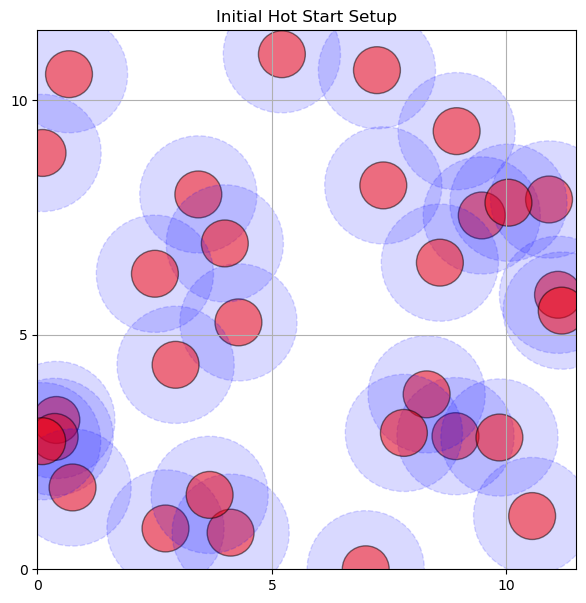

In [9]:
visualize(x, y, title="Initial Hot Start Setup")

In the beginning of the equilibrium simulation, we must provide a starting configuration. Most commonly we can choose between a random configuration ("Hot Start") or an ordered arrangement ("Cold Start").

Note: A random (hot) start usually involves overlap between the central cores of some particles and thus in principle infinite energy. This is not really a problem, provided that we make sure that such overlaps vanish during the approach to equilibrium. -> To deal with this initially run a pre-equilibration at an elevated temperature. This
will facilitate moves from hard core to soft core overlap. When the system is free from hard core overlap, we continue with a “regular” equilibration at the target temperature, which in turn is followed by a production run

### Additional info:

If we try to run the Monte Carlo directly on an overlapping state the algorithm will get stuck on every move resulting in $\Delta E = \infty - \infty$ (undefined) or $\Delta E = \infty$ (which is rejected all the time). To avoid this with the cap parameter we set a significantly higher potential value (but finite) value so overlapping particles can push off each other in this pre-equlibrium run.

In [10]:
def pre_equilibrate(x,y,T_high=5.0, U_cap=50.0, delta_pre_eq=0.50, max_sweeps=300):
    """Untangles overlapping particles from a hot start using a capped potential.

    Returns:
        x, y (np.ndarray): Particle layout with no hard overlaps.

        success (bool): True if all hard-core overlaps (r < sigma_0) were
        resolved.

        sweeps_taken (int): Number of actual sweeps required to resolve overlaps.
    """

    N = len(x)
    success = False
    sweeps_taken = max_sweeps

    for sweep in range(max_sweeps): # A single sweep attempts a trial move for every particle in the system.
# Sequential sweeps guarantee uniform sampling across all particles, preventing
# localized overlap bottlenecks that occur with purely random particle selection.
        
        for i in range(N): 
            # 1. Calculate the particles energy contribution with its N-1 neighbours
            E_old = U_single(x, y, i, cap=U_cap)
            x_old, y_old = x[i], y[i]

            # 2. Propose move with sigma_0/2 size in the positive/negative direction
            x[i] = (x[i] + np.random.uniform(-delta_pre_eq, delta_pre_eq)) % Length # While ensuring periodic boundary conditions
            y[i] = (y[i] + np.random.uniform(-delta_pre_eq, delta_pre_eq)) % Length

            # 3. Calculate the particles energy contribution after the move.
            E_new = U_single(x, y, i, cap=U_cap)
            dE = E_new - E_old

            # 4. We accept the move according to the boltzman distirbution
            if dE > 0 and np.random.rand() >= np.exp(-dE / T_high): # We use T_high to temporarly accept higher energy states thus we do not get stuck in the untangling.
                x[i], y[i] = x_old, y_old  # Reject move

        # 5. Check if all hard-core overlaps are resolved across the box
        # after every sweep we run a U_full to check wheter the conflict caused by core overlaps have resolved.
        if not np.isinf(U_full(x, y, cap=None)):
            success = True
            sweeps_taken = sweep + 1
            break

    return x, y, success, sweeps_taken

In [11]:
x,y,_,sweep = pre_equilibrate(x,y)

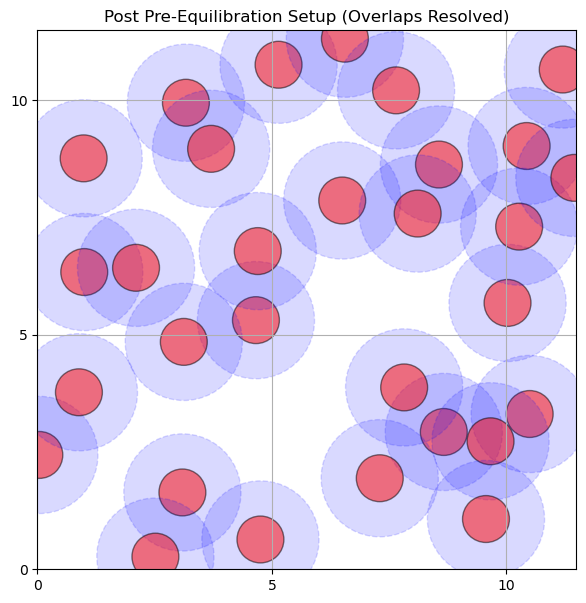

In [12]:
visualize(x, y, title="Post Pre-Equilibration Setup (Overlaps Resolved)")

In [13]:
sweep

7

# Quick Test 100 - On Pre-equilibrium

In [14]:
# 1. Prototype Parameters (N = 30, rho* = 0.227) 
np.random.seed(13) # We set a seed for reproductibility
N = 100
rho_target = 0.227
Length = np.sqrt(N / rho_target)  # Calculated from the reduced density

sigma_0 = 1.0  # Setting the hard core according to recommendation
sigma_1 = 2.5  # Same with the soft shoulder
epsilon = 1.0  # Set the energy to unit also


T_target = 0.1  # Target production temperature


#delta_prod = 0.15  # Step size tuned for rho* = 0.227 at T* = 0.1


In [15]:
x,y = hot_start()

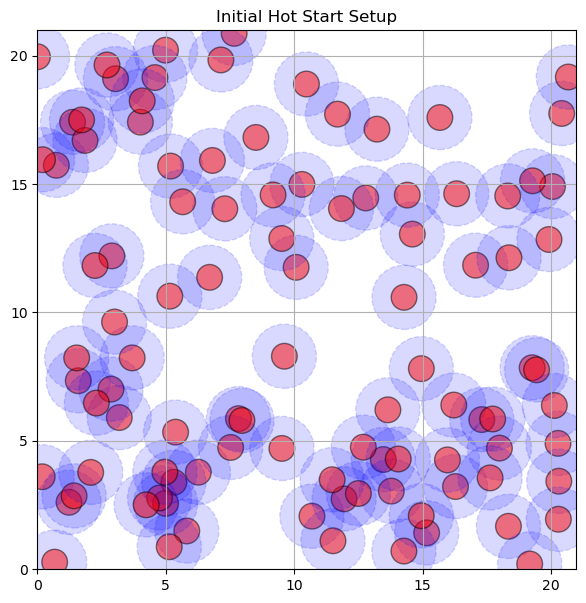

In [16]:
visualize(x, y, title="Initial Hot Start Setup")

In [17]:
x,y,_,sweep = pre_equilibrate(x,y) #It ran 0.2 sec


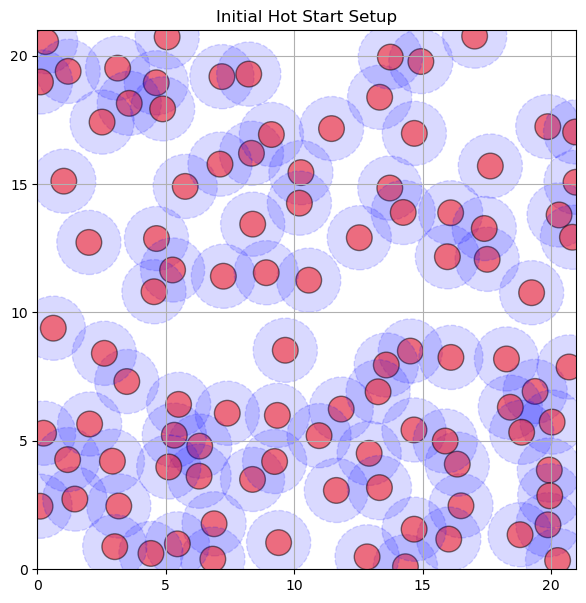

In [18]:
visualize(x, y, title="Initial Hot Start Setup")